<a href="https://colab.research.google.com/github/vyareyou/Deep-Fake-Detection-model/blob/main/Deep_fake_video_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install kaggle opencv-python tensorflow scikit-learn matplotlib

In [ ]:
import json

kaggle_dict = {
    "username": "browhatdoiduh",
    "key": "KGAT_a04b2c1e873e1c2ade5771f154c98cea"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

print("kaggle.json created!")

kaggle.json created!


In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle setup done!")

Kaggle setup done!


In [ ]:
!kaggle datasets download -d ucimachinelearning/deep-fake-detection-cropped-dataset -p /content/data

Dataset URL: https://www.kaggle.com/datasets/ucimachinelearning/deep-fake-detection-cropped-dataset
License(s): CC0-1.0
100% 666M/666M [00:19<00:00, 34.9MB/s]



In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!mkdir -p /content/data
!kaggle datasets download -d ucimachinelearning/deep-fake-detection-cropped-dataset -p /content/data
!unzip -q /content/data/deep-fake-detection-cropped-dataset.zip -d /content/data/cropped

Dataset URL: https://www.kaggle.com/datasets/ucimachinelearning/deep-fake-detection-cropped-dataset
License(s): CC0-1.0
deep-fake-detection-cropped-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!ls /content/data/cropped
!ls /content/data/cropped/DFDC_Dataset
!ls /content/data/cropped/DFDC_Dataset/Fake | head
!ls /content/data/cropped/DFDC_Dataset/Real | head

DFDC_Dataset
Fake  Real
aaagqkcdis.mp4
aaaoqepxnf.mp4
aabdnomlru.mp4
aabkwhhgwv.mp4
aafezqchru.mp4
aahslbfkop.mp4
aahsnkchkz.mp4
aajhbrxhzm.mp4
aakkdgsmvl.mp4
aaknzywids.mp4
aabqyygbaa.mp4
aajsqyyjni.mp4
aayfryxljh.mp4
abbgqbrdiz.mp4
abmjszfycr.mp4
abzdxpmmdb.mp4
acgzblwsgw.mp4
addknoverp.mp4
adgveaibmt.mp4
adkymkuove.mp4


In [ ]:
import os
import pandas as pd

base_path = "/content/data/cropped/DFDC_Dataset"
video_exts = (".mp4", ".avi", ".mov", ".mkv", ".webm")

data = []

for label_name in ["Fake", "Real"]:
    label_folder = os.path.join(base_path, label_name)
    label = label_name

    for root, dirs, files in os.walk(label_folder):
        for f in files:
            if f.lower().endswith(video_exts):
                data.append([os.path.join(root, f), label])

df_videos = pd.DataFrame(data, columns=["video_path", "label"])

print("Total videos:", len(df_videos))
print(df_videos["label"].value_counts())
df_videos.head()

Total videos: 3293
label
Real    1727
Fake    1566
Name: count, dtype: int64


,video_path,label
0,/content/data/cropped/DFDC_Dataset/Fake/ctgrad...,Fake
1,/content/data/cropped/DFDC_Dataset/Fake/aassna...,Fake
2,/content/data/cropped/DFDC_Dataset/Fake/achdei...,Fake
3,/content/data/cropped/DFDC_Dataset/Fake/cmyhcr...,Fake
4,/content/data/cropped/DFDC_Dataset/Fake/ebjdmh...,Fake


In [ ]:
import cv2
import numpy as np

output_base = "/content/extracted_frames"
os.makedirs(output_base, exist_ok=True)
os.makedirs(os.path.join(output_base, "Fake"), exist_ok=True)
os.makedirs(os.path.join(output_base, "Real"), exist_ok=True)

def save_frames_from_video(video_path, save_dir, num_frames=10):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return 0

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    saved = 0
    video_name = os.path.splitext(os.path.basename(video_path))[0]

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            out_path = os.path.join(save_dir, f"{video_name}_frame{saved}.jpg")
            cv2.imwrite(out_path, frame)
            saved += 1

    cap.release()
    return saved

In [ ]:
from sklearn.model_selection import train_test_split

fake_df = df_videos[df_videos["label"] == "Fake"].sample(n=min(100, len(df_videos[df_videos["label"] == "Fake"])), random_state=42)
real_df = df_videos[df_videos["label"] == "Real"].sample(n=min(100, len(df_videos[df_videos["label"] == "Real"])), random_state=42)

df_sample = pd.concat([fake_df, real_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Sample videos:", len(df_sample))
print(df_sample["label"].value_counts())

Sample videos: 200
label
Fake    100
Real    100
Name: count, dtype: int64


In [ ]:
total_saved = 0

for _, row in df_sample.iterrows():
    label = row["label"]
    video_path = row["video_path"]
    save_dir = os.path.join(output_base, label)
    saved = save_frames_from_video(video_path, save_dir, num_frames=10)
    total_saved += saved

print("Total frames saved:", total_saved)
print("Fake frames:", len(os.listdir(os.path.join(output_base, "Fake"))))
print("Real frames:", len(os.listdir(os.path.join(output_base, "Real"))))

Total frames saved: 2000
Fake frames: 1000
Real frames: 1000


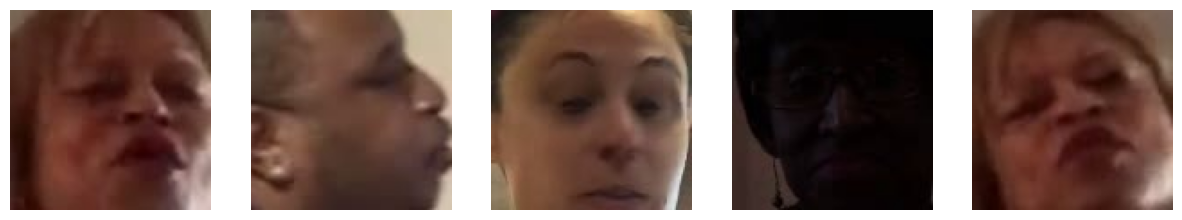

In [ ]:
import matplotlib.pyplot as plt

fake_frames = os.listdir(os.path.join(output_base, "Fake"))[:5]

plt.figure(figsize=(15, 4))
for i, fname in enumerate(fake_frames):
    img = cv2.imread(os.path.join(output_base, "Fake", fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32
DATASET_PATH = "/content/extracted_frames"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print("Class mapping:", train_generator.class_indices)

Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Class mapping: {'Fake': 0, 'Real': 1}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_frame_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 59s 745ms/step - accuracy: 0.6256 - loss: 0.6938 - val_accuracy: 0.5875 - val_loss: 0.6733
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 401ms/step - accuracy: 0.7069 - loss: 0.5752 - val_accuracy: 0.5475 - val_loss: 0.7838
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 408ms/step - accuracy: 0.7181 - loss: 0.5435 - val_accuracy: 0.6325 - val_loss: 0.6575
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 372ms/step - accuracy: 0.7487 - loss: 0.5108 - val_accuracy: 0.6325 - val_loss: 0.6769
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 371ms/step - accuracy: 0.7663 - loss: 0.4785 - val_accuracy: 0.6450 - val_loss: 0.6296


In [ ]:
best_model = tf.keras.models.load_model("/content/best_frame_model.keras")
print("Best model loaded.")

Best model loaded.


In [ ]:
loss, acc = best_model.evaluate(val_generator)
print("Validation Loss:", loss)
print("Validation Accuracy:", acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 444ms/step - accuracy: 0.6450 - loss: 0.6296
Validation Loss: 0.6296061873435974
Validation Accuracy: 0.6449999809265137


In [ ]:
def extract_frames_for_prediction(video_path, num_frames=10, img_size=224):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []

    if total_frames <= 0:
        cap.release()
        return np.array(frames)

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frame = frame.astype("float32") / 255.0
            frames.append(frame)

    cap.release()
    return np.array(frames)

def predict_video_with_frame_model(video_path, model, threshold=0.5):
    frames = extract_frames_for_prediction(video_path, num_frames=10, img_size=224)

    if len(frames) == 0:
        return "Unreadable video", 0.0, [], 0.0

    preds = model.predict(frames, verbose=0).flatten()
    avg_pred = preds.mean()

    label = "Real" if avg_pred >= threshold else "Fake"
    confidence = avg_pred if avg_pred >= threshold else 1 - avg_pred

    return label, float(confidence), preds, float(avg_pred)

In [ ]:
sample_video = df_sample.iloc[0]["video_path"]

label, confidence, frame_preds, avg_pred = predict_video_with_frame_model(sample_video, best_model)

print("Video:", sample_video)
print("Frame predictions:", frame_preds)
print("Average score:", avg_pred)
print("Final prediction:", label)
print("Confidence:", confidence)
print("Actual label:", df_sample.iloc[0]["label"])

Video: /content/data/cropped/DFDC_Dataset/Fake/dkeontafvh.mp4
Frame predictions: [0.73330235 0.7975948  0.75418514 0.6038619  0.5750431  0.4089954
 0.75851816 0.7126821  0.67787474 0.54413325]
Average score: 0.6566190719604492
Final prediction: Real
Confidence: 0.6566190719604492
Actual label: Fake


In [ ]:
import os

fake_folder = "/content/data/cropped/DFDC_Dataset/Fake"

videos = []

for f in os.listdir(fake_folder):
    path = os.path.join(fake_folder, f)
    size = os.path.getsize(path)
    videos.append((f, size))

# sort by size (bigger = usually better quality)
videos_sorted = sorted(videos, key=lambda x: x[1], reverse=True)

for v in videos_sorted[:10]:
    print(v)

('anuzdiqqnq.mp4', 442539)
('cdbmqliycy.mp4', 425296)
('crejnrpfwu.mp4', 401173)
('dwwninqprc.mp4', 388688)
('bjnvgindid.mp4', 385376)
('bptuspvmzq.mp4', 383318)
('bwyxdrzifm.mp4', 381554)
('cmvncstbkx.mp4', 377795)
('cjoykobwyh.mp4', 372688)
('atcfypvdpu.mp4', 372614)


In [ ]:
fake_folder = "/content/data/cropped/DFDC_Dataset/Fake"

results = []

top_videos = [
    'anuzdiqqng.mp4',
    'cdbmqliicy.mp4',
    'crejnrpfwu.mp4',
    'dwwnnqprc.mp4',
    'bjnvgimdtd.mp4',
    'bptuspmvzq.mp4',
    'bhyxdrzifm.mp4',
    'cmvncsbtkx.mp4',
    'cjoykobwyh.mp4',
    'atcfypvdpu.mp4'
]

for vid in top_videos:
    video_path = os.path.join(fake_folder, vid)
    label, confidence, _, avg_pred = predict_video_with_frame_model(video_path, best_model)

    results.append((vid, label, confidence, avg_pred))

for r in results:
    print(r)

('anuzdiqqng.mp4', 'Unreadable video', 0.0, 0.0)
('cdbmqliicy.mp4', 'Unreadable video', 0.0, 0.0)
('crejnrpfwu.mp4', 'Real', 0.8240402936935425, 0.8240402936935425)
('dwwnnqprc.mp4', 'Unreadable video', 0.0, 0.0)
('bjnvgimdtd.mp4', 'Unreadable video', 0.0, 0.0)
('bptuspmvzq.mp4', 'Unreadable video', 0.0, 0.0)
('bhyxdrzifm.mp4', 'Unreadable video', 0.0, 0.0)
('cmvncsbtkx.mp4', 'Unreadable video', 0.0, 0.0)
('cjoykobwyh.mp4', 'Real', 0.9878864288330078, 0.9878864288330078)
('atcfypvdpu.mp4', 'Real', 0.9727206230163574, 0.9727206230163574)


In [ ]:
results = []

for i in range(min(30, len(df_sample))):
    video_path = df_sample.iloc[i]["video_path"]
    true_label = df_sample.iloc[i]["label"]

    pred_label, confidence, _, avg_pred = predict_video_with_frame_model(video_path, best_model)
    results.append((os.path.basename(video_path), true_label, pred_label, confidence, avg_pred))

for r in results:
    print(r)

('dkeontafvh.mp4', 'Fake', 'Real', 0.6566190719604492, 0.6566190719604492)
('baklbjkzeq.mp4', 'Fake', 'Fake', 0.7168353199958801, 0.2831646800041199)
('doxeyanlla.mp4', 'Fake', 'Real', 0.5022427439689636, 0.5022427439689636)
('fmztdticln.mp4', 'Real', 'Real', 0.8404167890548706, 0.8404167890548706)
('xzayxilesu.mp4', 'Real', 'Real', 0.9887641668319702, 0.9887641668319702)
('wlurvqspwf.mp4', 'Real', 'Real', 0.7264448404312134, 0.7264448404312134)
('bqlgvoexky.mp4', 'Fake', 'Fake', 0.5167721509933472, 0.48322781920433044)
('ufiwltnbqn.mp4', 'Real', 'Real', 0.8612874746322632, 0.8612874746322632)
('lbgnipxpnx.mp4', 'Real', 'Real', 0.8111603856086731, 0.8111603856086731)
('abgunexqlc.mp4', 'Fake', 'Real', 0.8963101506233215, 0.8963101506233215)
('cswvrrtrfi.mp4', 'Fake', 'Fake', 0.6191278696060181, 0.3808721601963043)
('apeftlgrqg.mp4', 'Real', 'Real', 0.8774158358573914, 0.8774158358573914)
('pgvkkpnfrg.mp4', 'Real', 'Real', 0.8582491874694824, 0.8582491874694824)
('aorwnetwso.mp4', 'Fake

In [ ]:
correct_fake = [r for r in results if r[1] == "Fake" and r[2] == "Fake"]
correct_real = [r for r in results if r[1] == "Real" and r[2] == "Real"]

print("Correct fake detections:")
for r in correct_fake[:10]:
    print(r)

print("\nCorrect real detections:")
for r in correct_real[:10]:
    print(r)

Correct fake detections:
('baklbjkzeq.mp4', 'Fake', 'Fake', 0.7168353199958801, 0.2831646800041199)
('bqlgvoexky.mp4', 'Fake', 'Fake', 0.5167721509933472, 0.48322781920433044)
('cswvrrtrfi.mp4', 'Fake', 'Fake', 0.6191278696060181, 0.3808721601963043)
('bcjuiazvil.mp4', 'Fake', 'Fake', 0.6214858889579773, 0.3785141110420227)
('bbmstrmoaf.mp4', 'Fake', 'Fake', 0.7801656126976013, 0.21983440220355988)
('cchjntpryf.mp4', 'Fake', 'Fake', 0.6135326623916626, 0.3864673674106598)
('eaewlbhlxk.mp4', 'Fake', 'Fake', 0.6644310355186462, 0.33556896448135376)
('dargqdtmnl.mp4', 'Fake', 'Fake', 0.8312970399856567, 0.16870297491550446)

Correct real detections:
('fmztdticln.mp4', 'Real', 'Real', 0.8404167890548706, 0.8404167890548706)
('xzayxilesu.mp4', 'Real', 'Real', 0.9887641668319702, 0.9887641668319702)
('wlurvqspwf.mp4', 'Real', 'Real', 0.7264448404312134, 0.7264448404312134)
('ufiwltnbqn.mp4', 'Real', 'Real', 0.8612874746322632, 0.8612874746322632)
('lbgnipxpnx.mp4', 'Real', 'Real', 0.81116038

In [ ]:
demo_fake_videos = [r[0] for r in correct_fake[:5]]
demo_real_videos = [r[0] for r in correct_real[:5]]

print("Demo fake videos:", demo_fake_videos)
print("Demo real videos:", demo_real_videos)

Demo fake videos: ['baklbjkzeq.mp4', 'bqlgvoexky.mp4', 'cswvrrtrfi.mp4', 'bcjuiazvil.mp4', 'bbmstrmoaf.mp4']
Demo real videos: ['fmztdticln.mp4', 'xzayxilesu.mp4', 'wlurvqspwf.mp4', 'ufiwltnbqn.mp4', 'lbgnipxpnx.mp4']


In [ ]:
video_path = os.path.join("/content/data/cropped/DFDC_Dataset/Fake", "dkeontafvh.mp4")

label, confidence, frame_preds, avg_pred = predict_video_with_frame_model(video_path, best_model)

print("Video:", video_path)
print("Frame predictions:", frame_preds)
print("Average score:", avg_pred)
print("Final prediction:", label)
print("Confidence:", confidence)

Video: /content/data/cropped/DFDC_Dataset/Fake/dkeontafvh.mp4
Frame predictions: [0.73330235 0.7975948  0.75418514 0.6038619  0.5750431  0.4089954
 0.75851816 0.7126821  0.67787474 0.54413325]
Average score: 0.6566190719604492
Final prediction: Real
Confidence: 0.6566190719604492


In [ ]:
from google.colab import files
import os

demo_fake_videos = [
    "cswvrrtrfi.mp4",
]

for vid in demo_fake_videos:
    path = os.path.join("/content/data/cropped/DFDC_Dataset/Fake", vid)
    files.download(path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

uploaded = files.upload()
uploaded_video = list(uploaded.keys())[0]

label, confidence, frame_preds, avg_pred = predict_video_with_frame_model(uploaded_video, best_model)

print("Uploaded video:", uploaded_video)
print("Frame predictions:", frame_preds)
print("Average score:", avg_pred)
print("Final prediction:", label)
print("Confidence:", confidence)

Saving video_17.mp4 to video_17 (2).mp4
Uploaded video: video_17 (2).mp4
Frame predictions: [0.59687406 0.37461168 0.4905899  0.25087085 0.19194601 0.2927582
 0.45711103 0.4179533  0.29252487 0.4434818 ]
Average score: 0.3808721601963043
Final prediction: Fake
Confidence: 0.6191278696060181


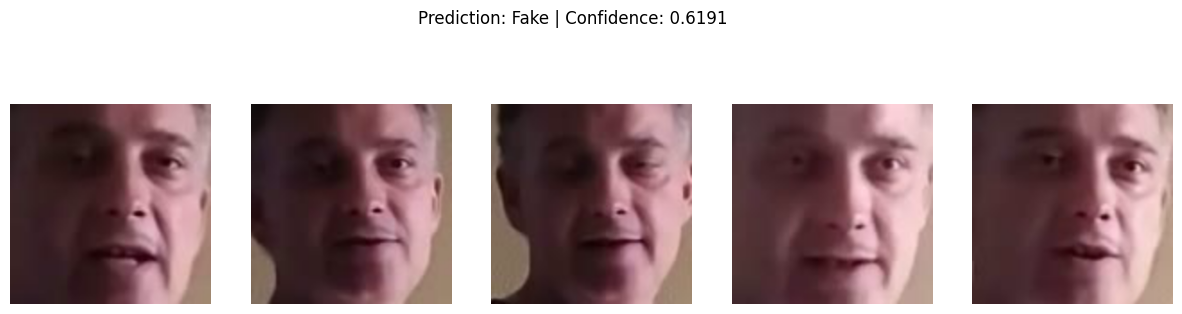

In [ ]:
frames = extract_frames_for_prediction(uploaded_video, num_frames=5, img_size=224)

plt.figure(figsize=(15, 4))
for i in range(len(frames)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(frames[i])
    plt.axis("off")

plt.suptitle(f"Prediction: {label} | Confidence: {confidence:.4f}")
plt.show()